**FCD - Projeto prático**


Nome: Daniel Costa Andrade

# PARTE 1:  INGESTÃO, LIMPEZA E ENGENHARIA DE ATRIBUTOS

In [1]:
!pip install shap scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from scipy import stats

sns.set_theme(style="whitegrid")

url_torneios = "https://raw.githubusercontent.com/jfjelstul/worldcup/master/data-csv/tournaments.csv"
url_partidas = "https://raw.githubusercontent.com/jfjelstul/worldcup/master/data-csv/matches.csv"

df_torneios = pd.read_csv(url_torneios)
df_partidas = pd.read_csv(url_partidas)

df_partidas['match_date'] = pd.to_datetime(df_partidas['match_date'])
df_partidas['total_goals'] = df_partidas['home_team_score'] + df_partidas['away_team_score']
df_partidas['goal_difference'] = abs(df_partidas['home_team_score'] - df_partidas['away_team_score'])

df_consolidado = pd.merge(
    df_partidas,
    df_torneios[['tournament_id', 'year', 'host_country', 'winner']],
    on='tournament_id',
    how='left'
)

df_mandantes = df_consolidado[['match_id', 'year', 'stage_name', 'home_team_name', 'home_team_score', 'away_team_score']].copy()
df_mandantes.columns = ['match_id', 'year', 'stage_name', 'equipe', 'gols_feitos', 'gols_sofridos']
df_mandantes['vitoria'] = df_mandantes['gols_feitos'] > df_mandantes['gols_sofridos']
df_mandantes['empate'] = df_mandantes['gols_feitos'] == df_mandantes['gols_sofridos']

df_visitantes = df_consolidado[['match_id', 'year', 'stage_name', 'away_team_name', 'away_team_score', 'home_team_score']].copy()
df_visitantes.columns = ['match_id', 'year', 'stage_name', 'equipe', 'gols_feitos', 'gols_sofridos']
df_visitantes['vitoria'] = df_visitantes['gols_feitos'] > df_visitantes['gols_sofridos']
df_visitantes['empate'] = df_visitantes['gols_feitos'] == df_visitantes['gols_sofridos']

df_equipes = pd.concat([df_mandantes, df_visitantes], ignore_index=True)

print("Setup concluído! Base pronta para análise.")
display(df_consolidado.head())

Setup concluído! Base pronta para análise.


,key_id,tournament_id,tournament_name,match_id,match_name,stage_name,group_name,group_stage,knockout_stage,replayed,...,away_team_score_penalties,result,home_team_win,away_team_win,draw,total_goals,goal_difference,year,host_country,winner
0,1,WC-1930,1930 FIFA Men's World Cup,M-1930-01,France vs Mexico,group stage,Group 1,1,0,0,...,0,home team win,1,0,0,5,3,1930,Uruguay,Uruguay
1,2,WC-1930,1930 FIFA Men's World Cup,M-1930-02,United States vs Belgium,group stage,Group 4,1,0,0,...,0,home team win,1,0,0,3,3,1930,Uruguay,Uruguay
2,3,WC-1930,1930 FIFA Men's World Cup,M-1930-03,Yugoslavia vs Brazil,group stage,Group 2,1,0,0,...,0,home team win,1,0,0,3,1,1930,Uruguay,Uruguay
3,4,WC-1930,1930 FIFA Men's World Cup,M-1930-04,Romania vs Peru,group stage,Group 3,1,0,0,...,0,home team win,1,0,0,4,2,1930,Uruguay,Uruguay
4,5,WC-1930,1930 FIFA Men's World Cup,M-1930-05,Argentina vs France,group stage,Group 1,1,0,0,...,0,home team win,1,0,0,1,1,1930,Uruguay,Uruguay


# PARTE 2: ANÁLISE DE DADOS AVANÇADA COM PANDAS

In [ ]:
def ordenar_confronto(row):
    teams = sorted([str(row['home_team_name']), str(row['away_team_name'])])
    return f"{teams[0]} x {teams[1]}"
df_confrontos = df_consolidado.copy()
df_confrontos['confronto'] = df_confrontos.apply(ordenar_confronto, axis=1)
top_confronto = df_confrontos['confronto'].value_counts().idxmax()
df_top = df_confrontos[df_confrontos['confronto'] == top_confronto]
t1, t2 = top_confronto.split(' x ')
v_t1 = len(df_top[((df_top['home_team_name'] == t1) & (df_top['result'] == 'home team win')) | ((df_top['away_team_name'] == t1) & (df_top['result'] == 'away team win'))])
v_t2 = len(df_top[((df_top['home_team_name'] == t2) & (df_top['result'] == 'home team win')) | ((df_top['away_team_name'] == t2) & (df_top['result'] == 'away team win'))])
empates = len(df_top[df_top['result'] == 'draw'])
print("Q1) Rivalidade:", {"confronto": top_confronto, "jogos": len(df_top), f"vitorias_{t1}": v_t1, f"vitorias_{t2}": v_t2, "empates": empates})

q2_res = len(df_consolidado[(df_consolidado['extra_time'] == 1) & (df_consolidado['penalty_shootout'] == 0)])
print("Q2) Decididos na Prorrogação:", q2_res)

clean_sheets = df_equipes[df_equipes['gols_sofridos'] == 0]
print("Q3) Mais Clean Sheets:", {clean_sheets['equipe'].value_counts().idxmax(): int(clean_sheets['equipe'].value_counts().max())})

ed_host = df_consolidado[['year', 'host_country']].drop_duplicates()
fases_semi = ['semi-finals', 'third-place match', 'final', 'semi-final', 'match for third place']
j_semi = df_consolidado[df_consolidado['stage_name'].str.lower().isin(fases_semi)]
host_semi = 0
for _, r in ed_host.iterrows():
    times = set(j_semi[j_semi['year'] == r['year']]['home_team_name']).union(set(j_semi[j_semi['year'] == r['year']]['away_team_name']))
    if r['host_country'] in times: host_semi += 1
print("Q4) Anfitriões na Semi (%):", round((host_semi / len(ed_host)) * 100, 2))

f_grupos = df_equipes[df_equipes['stage_name'].str.lower().str.contains('group')]
m_gols = f_grupos.groupby('equipe')['gols_feitos'].mean()
print("Q5) Maior Média Gols Grupos:", {m_gols.idxmax(): round(m_gols.max(), 2)})

finais = df_consolidado[df_consolidado['stage_name'].str.lower() == 'final']
print("Q6) Finais:", {"media_gols": round(finais['total_goals'].mean(), 2), "maior_diff": int(finais['goal_difference'].max()), "jogos": finais[finais['goal_difference'] == finais['goal_difference'].max()]['match_name'].tolist()})

s_xx = df_consolidado[df_consolidado['year'] <= 1998]
s_xxi = df_consolidado[df_consolidado['year'] >= 2002]
t_xx = (len(s_xx[s_xx['result'] == 'away team win']) / len(s_xx)) * 100
t_xxi = (len(s_xxi[s_xxi['result'] == 'away team win']) / len(s_xxi)) * 100
print("Q7) Taxa Vitória Visitante:", {"Séc XX (%)": round(t_xx, 2), "Séc XXI (%)": round(t_xxi, 2), "Tendência": "aumentou" if t_xxi > t_xx else "diminuiu"})

total_sof = df_equipes.groupby('equipe')['gols_sofridos'].sum()
print("Q8) Maior Vítima Histórica:", {total_sof.idxmax(): int(total_sof.max())})

tot_j = df_equipes.groupby('equipe')['match_id'].count()
emp_j = df_equipes[df_equipes['empate'] == True].groupby('equipe')['match_id'].count()
pct_emp = (emp_j / tot_j * 100).fillna(0)
print("Q9) Maior % Empates:", {pct_emp.idxmax(): round(pct_emp.max(), 2)})

part = df_equipes.groupby('equipe')['year'].nunique()
sel_filt = part[part <= 3].index
f_avanc = ['quarter-finals', 'semi-finals', 'third-place match', 'final', 'quarter-final', 'semi-final', 'match for third place']
zeb = df_equipes[(df_equipes['equipe'].isin(sel_filt)) & (df_equipes['stage_name'].str.lower().isin(f_avanc))]
print("Q10) Zebras em Quartas ou mais:", zeb['equipe'].unique().tolist())


Q1) Rivalidade: {'confronto': 'Brazil x Sweden', 'jogos': 10, 'vitorias_Brazil': 6, 'vitorias_Sweden': 2, 'empates': 2}
Q2) Decididos na Prorrogação: 46
Q3) Mais Clean Sheets: {'Brazil': 65}
Q4) Anfitriões na Semi (%): 43.33
Q5) Maior Média Gols Grupos: {'Germany': 2.75}
Q6) Finais: {'media_gols': np.float64(3.55), 'maior_diff': 3, 'jogos': ['Brazil vs Sweden', 'Brazil vs Italy', 'Brazil vs France', 'United States vs Japan']}
Q7) Taxa Vitória Visitante: {'Séc XX (%)': 19.46, 'Séc XXI (%)': 35.1, 'Tendência': 'aumentou'}
Q8) Maior Vítima Histórica: {'Brazil': 148}
Q9) Maior % Empates: {'Angola': 66.67}
Q10) Zebras em Quartas ou mais: ['Republic of Ireland', 'Senegal', 'Cuba', 'Wales', 'Northern Ireland', 'Chinese Taipei', 'Turkey', 'Ukraine']


# PARTE 3: VISUALIZAÇÃO DE DADOS

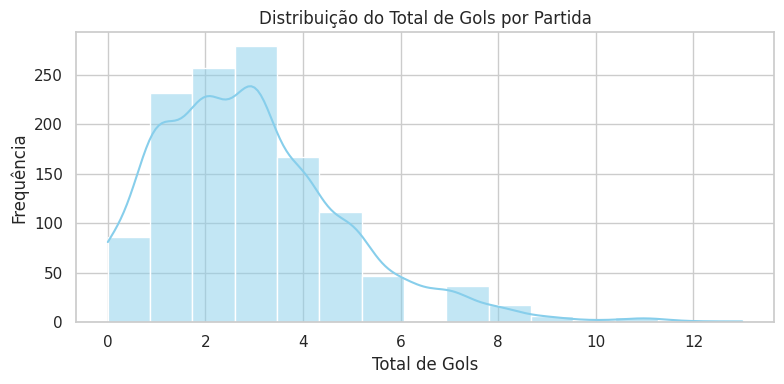

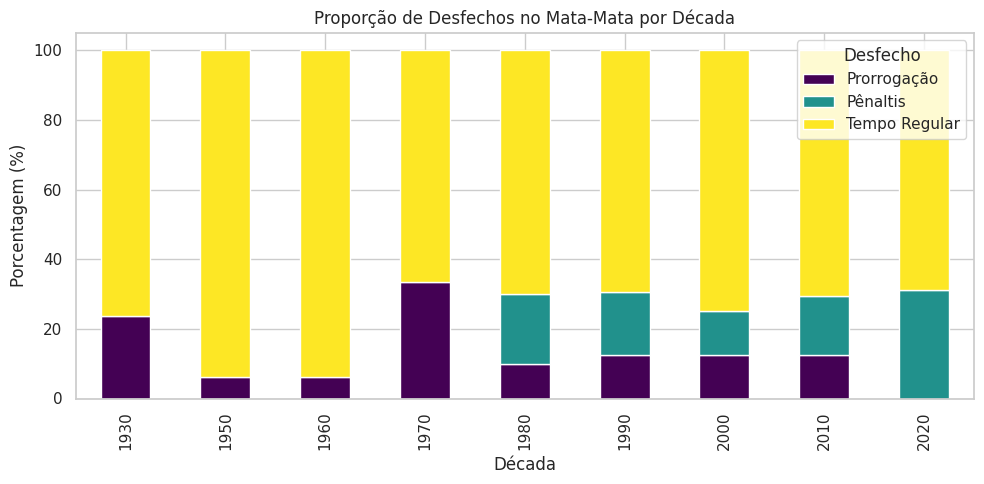

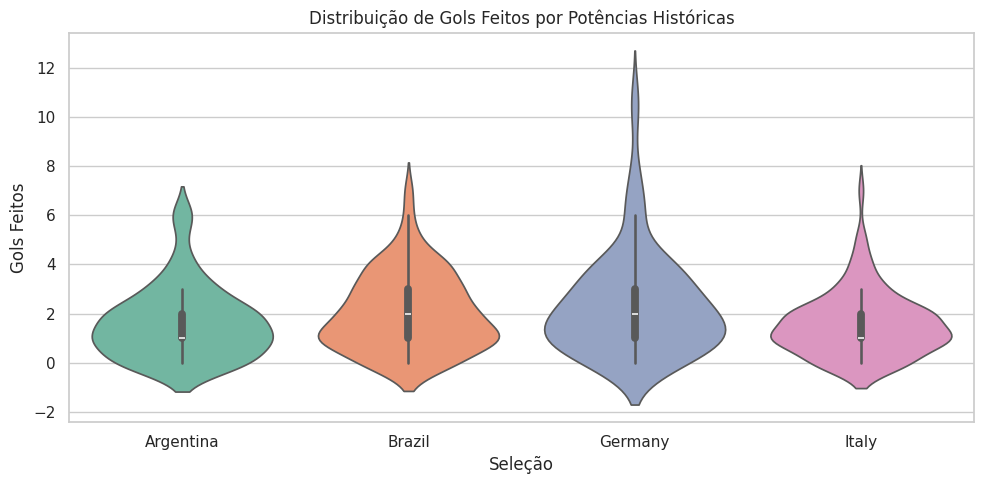

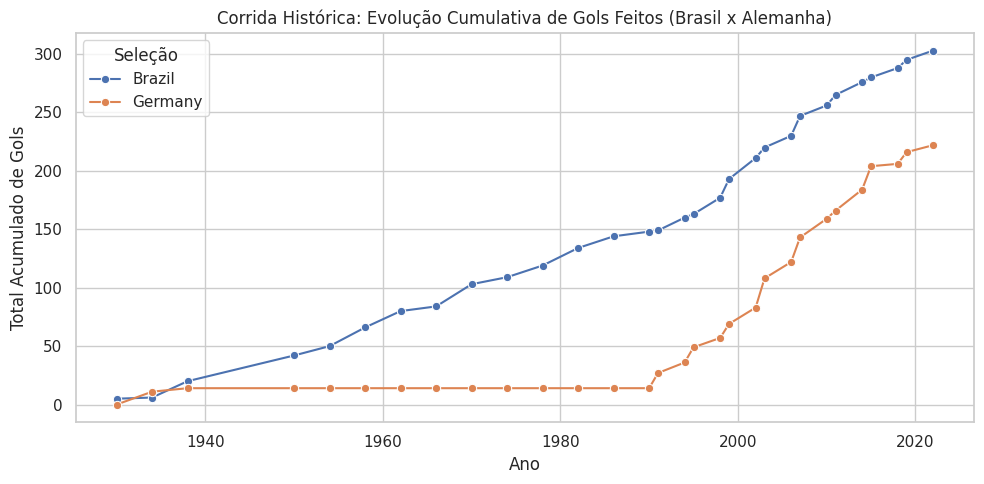

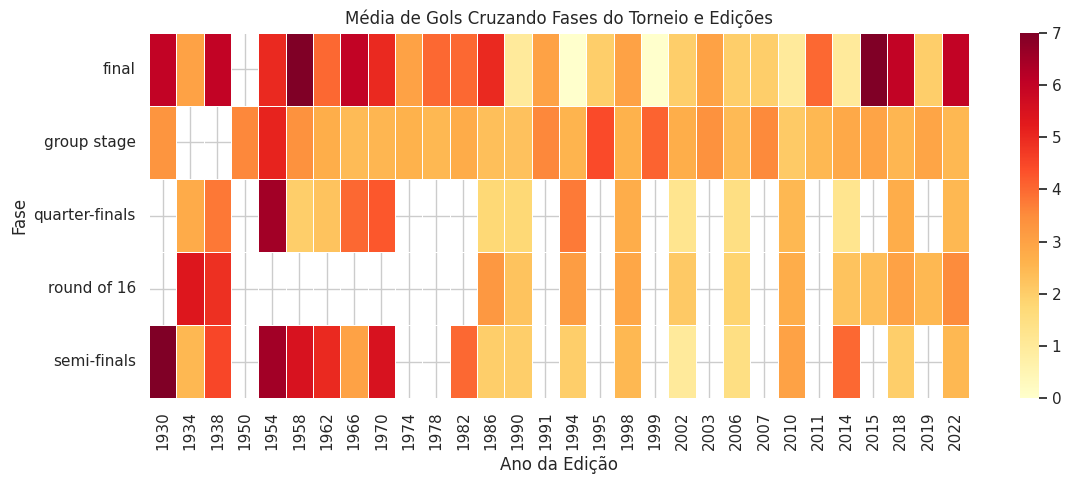

In [ ]:
# Q11) Histograma com KDE
plt.figure(figsize=(8, 4))
sns.histplot(df_consolidado['total_goals'], kde=True, color='skyblue', bins=15)
plt.title('Distribuição do Total de Gols por Partida')
plt.xlabel('Total de Gols')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

# Q12) Gráfico de Barras Empilhadas
df_mm = df_consolidado[df_consolidado['knockout_stage'] == 1].copy()
df_mm['decada'] = (df_mm['year'] // 10) * 10
df_mm['resultado_final'] = df_mm.apply(lambda r: 'Pênaltis' if r['penalty_shootout'] == 1 else ('Prorrogação' if r['extra_time'] == 1 else 'Tempo Regular'), axis=1)
pivot_mm = pd.crosstab(df_mm['decada'], df_mm['resultado_final'], normalize='index') * 100
pivot_mm.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='viridis')
plt.title('Proporção de Desfechos no Mata-Mata por Década')
plt.ylabel('Porcentagem (%)')
plt.xlabel('Década')
plt.legend(title='Desfecho')
plt.tight_layout()
plt.show()

# Q13) Violin Plot
potencias = ['Brazil', 'Germany', 'Argentina', 'Italy']
df_pot = df_equipes[df_equipes['equipe'].isin(potencias)]
plt.figure(figsize=(10, 5))
sns.violinplot(data=df_pot, x='equipe', y='gols_feitos', hue='equipe', palette='Set2', legend=False)
plt.title('Distribuição de Gols Feitos por Potências Históricas')
plt.xlabel('Seleção')
plt.ylabel('Gols Feitos')
plt.tight_layout()
plt.show()

# Q14) Linhas Múltiplas Cumulativo
gols_ano = df_equipes[df_equipes['equipe'].isin(['Brazil', 'Germany'])].groupby(['year', 'equipe'])['gols_feitos'].sum().unstack().fillna(0)
gols_cum = gols_ano.cumsum()
plt.figure(figsize=(10, 5))
sns.lineplot(data=gols_cum, dashes=False, marker='o')
plt.title('Corrida Histórica: Evolução Cumulativa de Gols Feitos (Brasil x Alemanha)')
plt.xlabel('Ano')
plt.ylabel('Total Acumulado de Gols')
plt.legend(title='Seleção')
plt.tight_layout()
plt.show()

# Q15) Heatmap Pivotado
df_fases = df_consolidado[df_consolidado['stage_name'].str.lower().isin(['group stage', 'round of 16', 'quarter-finals', 'semi-finals', 'final'])].copy()
pivot_heatmap = df_fases.pivot_table(values='total_goals', index='stage_name', columns='year', aggfunc='mean')
plt.figure(figsize=(12, 5))
sns.heatmap(pivot_heatmap, cmap='YlOrRd', annot=False, linewidths=.5)
plt.title('Média de Gols Cruzando Fases do Torneio e Edições')
plt.xlabel('Ano da Edição')
plt.ylabel('Fase')
plt.tight_layout()
plt.show()

PARTE 4: CORRELAÇÃO DE DADOS

In [ ]:
p_corr, _ = stats.pearsonr(df_consolidado['year'], df_consolidado['total_goals'])
s_corr, _ = stats.spearmanr(df_consolidado['year'], df_consolidado['total_goals'])
print("Q16) Correlação Temporal Gols:", {"pearson": round(p_corr, 4), "spearman": round(s_corr, 4)})

corr_diff, p_val_diff = stats.spearmanr(df_consolidado['year'], df_consolidado['goal_difference'])
print("Q17) Correlação Equilíbrio (Diff Gols):", {"correlacao": round(corr_diff, 4), "p_valor": p_val_diff})

df_mm_corr = df_consolidado[df_consolidado['stage_name'].str.lower().isin(['round of 16', 'quarter-finals', 'semi-finals', 'final'])].copy()
df_mm_corr['stage_encoded'] = df_mm_corr['stage_name'].str.lower().map({'round of 16': 1, 'quarter-finals': 2, 'semi-finals': 3, 'final': 4})
df_mm_corr = df_mm_corr.dropna(subset=['stage_encoded'])
corr_cat, _ = stats.spearmanr(df_mm_corr['stage_encoded'], df_mm_corr['penalty_shootout'])
print("Q18) Correlação Avanço de Fase x Pênaltis:", round(corr_cat, 4))


Q16) Correlação Temporal Gols: {'pearson': np.float64(-0.1799), 'spearman': np.float64(-0.1277)}
Q17) Correlação Equilíbrio (Diff Gols): {'correlacao': np.float64(-0.0695), 'p_valor': np.float64(0.014118973417457837)}
Q18) Correlação Avanço de Fase x Pênaltis: 0.0494


# PARTE 5: ESTATÍSTICA E PROBABILIDADE AVANÇADA

In [ ]:
lamb = df_consolidado['total_goals'].mean()
prob_t = stats.poisson.pmf(0, lamb) * 100
pct_r = (len(df_consolidado[df_consolidado['total_goals'] == 0]) / len(df_consolidado)) * 100
print("Q19) Poisson 0x0:", {"lambda": round(lamb, 4), "teorica_pct": round(prob_t, 2), "real_pct": round(pct_r, 2)})

j_prorr = df_consolidado[df_consolidado['extra_time'] == 1]
j_pen = j_prorr[j_prorr['penalty_shootout'] == 1]
print("Q20) Probabilidade Bayes Empírica (Pênaltis | Prorrogação):", round((len(j_pen) / len(j_prorr)) * 100, 2))

df_t = df_consolidado.copy()
df_t['is_host_playing'] = df_t.apply(lambda r: (r['home_team_name'] == r['host_country']) or (r['away_team_name'] == r['host_country']), axis=1)
g_com = df_t[df_t['is_host_playing'] == True]['total_goals']
g_sem = df_t[df_t['is_host_playing'] == False]['total_goals']
t_stat, p_val = stats.ttest_ind(g_com, g_sem, equal_var=False)
print("Q21) Teste T (Gols com vs sem Anfitrião):", {"t_stat": round(t_stat, 4), "p_valor": p_val})

Q19) Poisson 0x0: {'lambda': np.float64(2.9143), 'teorica_pct': np.float64(5.42), 'real_pct': 6.89}
Q20) Probabilidade Bayes Empírica (Pênaltis | Prorrogação): 47.73
Q21) Teste T (Gols com vs sem Anfitrião): {'t_stat': np.float64(-0.102), 'p_valor': np.float64(0.9188335740520759)}


# PARTE 6: INTELIGÊNCIA ARTIFICIAL E EXPLICABILIDADE

Q22) Regressão Linear: {'coeficientes': [-0.01571888649407792, 0.26892610134788353], 'intercepto': np.float64(34.19871864047523)}
Q23) Regressão Logística (Coeficientes): {'home_gols_feitos_media': np.float64(1.2861882104041962), 'home_gols_sofridos_media': np.float64(-0.9049741166990709), 'away_gols_feitos_media': np.float64(-0.6003614151128508), 'away_gols_sofridos_media': np.float64(1.1400562166137316)}


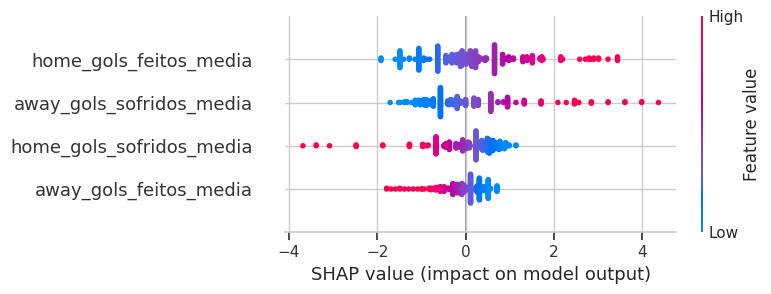

In [ ]:
X_q22 = df_consolidado[['year', 'knockout_stage']]
y_q22 = df_consolidado['total_goals']
X_tr22, X_te22, y_tr22, y_te22 = train_test_split(X_q22, y_q22, test_size=0.2, random_state=42)
model_lin = LinearRegression().fit(X_tr22, y_tr22)
print("Q22) Regressão Linear:", {"coeficientes": model_lin.coef_.tolist(), "intercepto": model_lin.intercept_})

m_gols_ed = df_equipes.groupby(['year', 'equipe']).agg(m_feitos=('gols_feitos', 'mean'), m_sofridos=('gols_sofridos', 'mean')).reset_index()
df_ia = df_consolidado.copy()
df_ia = df_ia.merge(m_gols_ed, left_on=['year', 'home_team_name'], right_on=['year', 'equipe'], how='left').rename(columns={'m_feitos': 'home_gols_feitos_media', 'm_sofridos': 'home_gols_sofridos_media'})
df_ia = df_ia.merge(m_gols_ed, left_on=['year', 'away_team_name'], right_on=['year', 'equipe'], how='left').rename(columns={'m_feitos': 'away_gols_feitos_media', 'm_sofridos': 'away_gols_sofridos_media'})
features = ['home_gols_feitos_media', 'home_gols_sofridos_media', 'away_gols_feitos_media', 'away_gols_sofridos_media']
df_ia = df_ia.dropna(subset=features)

X_ia = df_ia[features]
y_ia = df_ia['home_team_win']
X_tr, X_te, y_tr, y_te = train_test_split(X_ia, y_ia, test_size=0.2, random_state=42)

model_log = LogisticRegression().fit(X_tr, y_tr)
print("Q23) Regressão Logística (Coeficientes):", dict(zip(features, model_log.coef_[0])))

explainer = shap.LinearExplainer(model_log, X_tr, max_samples=X_tr.shape[0])
shap_values = explainer.shap_values(X_te)

plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, X_te, feature_names=features)